# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 12</span>
### <span style= "color: black" > Es12.1


Lo scopo di questo esercizio è quello di implementare e addestrare una rete neurale in grado di eseguire una classificazione di cifre scritte a mano da $0$ a $9$. A tal fine, è stata utilizzata una *Rete neurale profonda (Deep Neural Network, DNN)*, oppure una *Rete neurale convoluzionale (Convolutional Neural Network, CNN)*, la quale accetta come input un'immagine contenente la cifra scritta a mano e fornisce come output la classe di appartenenza della cifra(indicata da un numero intero da $0$ a $9$).

Si vogliono confrontare le performance dei modelli realizzati con DNN e con CNN.  

Per allenare la NN si è utilizzato il dataset `MNIST`, che comprende $70000$ immagini di cifre da $0$ a $9$ scritte a mano, ciascuna di $28$ x $28$ pixel con canale singolo (greyscale) a $8$ bit ($256$ valori possibili per pixel, da $0$ a $255$). 

Gli step dell'esercizio sono i seguenti:
1. Caricamento e processing dei dati
2. Definizione del tipo di NN e della sua architettura
3. Selezione di ottimizzatore, loss function e metriche
4. Training del modello
5. Valutazione delle performance

In questo esercizio si utilizza un DNN. Il modello è simile a quello usato nell'Esercitazione 11, dove si sono impiegati diversi layer in cui ogni neurone è connesso a tutti i neuroni del layer precedente

In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adamax, Nadam

2026-07-21 23:20:56.388912: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
rows, cols = 28, 28  # Input size (image), in pixels
classes = 10         # Output size (number of classes): the 10 digits


# Step #1: Data loading and preprocessing

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()  # Create the training and test sets

X_train = X_train.reshape(X_train.shape[0], rows*cols)  # Reshape the images into vectors of size 28x28=784
X_test = X_test.reshape(X_test.shape[0], rows*cols)

X_train = X_train.astype('float32')/255         # Rescale each pixel value to [0,1]
X_test = X_test.astype('float32')/255

Y_train = keras.utils.to_categorical(Y_train, classes)   # Convert the class vectors into binary class matrices
Y_test = keras.utils.to_categorical(Y_test, classes)


# Step #2: Definition of the neural network type (DNN) and its architecture
def create_DNN():
    model = Sequential()                              # Neural network model
    model.add(Input(shape=(rows*cols,)))              # Input variable
    model.add(Dense(400, activation='relu'))          # First dense layer
    model.add(Dense(100, activation='relu'))          # Second dense layer
    model.add(Dropout(0.5))                           # Apply dropout with rate=0.5
    model.add(Dense(classes, activation='softmax'))   # Soft-max layer
    return model


# Step #3: Selection of the optimizer, loss function, and metrics (model compilation)
def compile_DNN(optimizer):
    model=create_DNN()     # Create the model
    model.compile(loss=keras.losses.categorical_crossentropy,optimizer=optimizer,metrics=['acc'])  # Compile the model
    return model


# Step #4: Model training
def train_DNN(optimizer, N_epochs):
    model = compile_DNN(optimizer)  # Create the DNN
    history = model.fit(X_train, Y_train, batch_size=32, epochs=N_epochs, shuffle=True, verbose=0, validation_data=(X_test, Y_test))  # Train the DNN
    loss, accuracy = model.evaluate(X_test, Y_test, batch_size=32, verbose=0)  # Evaluate the model on the test set
    return model, history, loss, accuracy

Due scelte cruciali per un corretto addestramento del DNN sono quella dell'ottimizzatore e quella del numero di epoche. Per questa ragione, è importante confrontare diversi ottimizzatori, osservando come essi si comportano al variare del numero di epoche. In questo modo, si può individuare il miglior compromesso tra accuratezza e loss.

Nell’analisi è stato fissato $N_{\mathrm{epochs}}=20$, per confrontare le prestazioni degli ottimizzatori `sgd`, `adam` e `rmsprop`. E' stato scelto di non riportare un confronto dettagliato dei modelli con i diversi ottimizzatori, in quanto il tempo di compilazione del notebook risulterebbe troppo elevato. Si riporta tuttavia che è stato scelto l'ottimizzatore `adam`, in quanto poiché offre il miglior compromesso tra stabilità nella convergenza, capacità di generalizzazione e velocità di apprendimento.

Si è poi posto $N_{\mathrm{epochs}}=15$. Si è osservato che, con `adam`, una buona convergenza è garantita già con $N_{\mathrm{epochs}}\simeq5$, mentre con $N_{\mathrm{epochs}}>20$ non si hanno significativi miglioramenti nelle prestazioni e sembrano apparire fenomeni di overfitting.

Di seguito si mostrano i risultati ottenuti dopo aver addestrato la DNN sul dataset `MNIST` e dopo averlo testato sul test set.
Le predizioni vengono quindi confrontate con le etichette reali, così da valutare visivamente la qualità della classificazione.

In [7]:
# DNN
model, history, loss, accuracy = train_DNN(optimizer='adam', N_epochs=15)

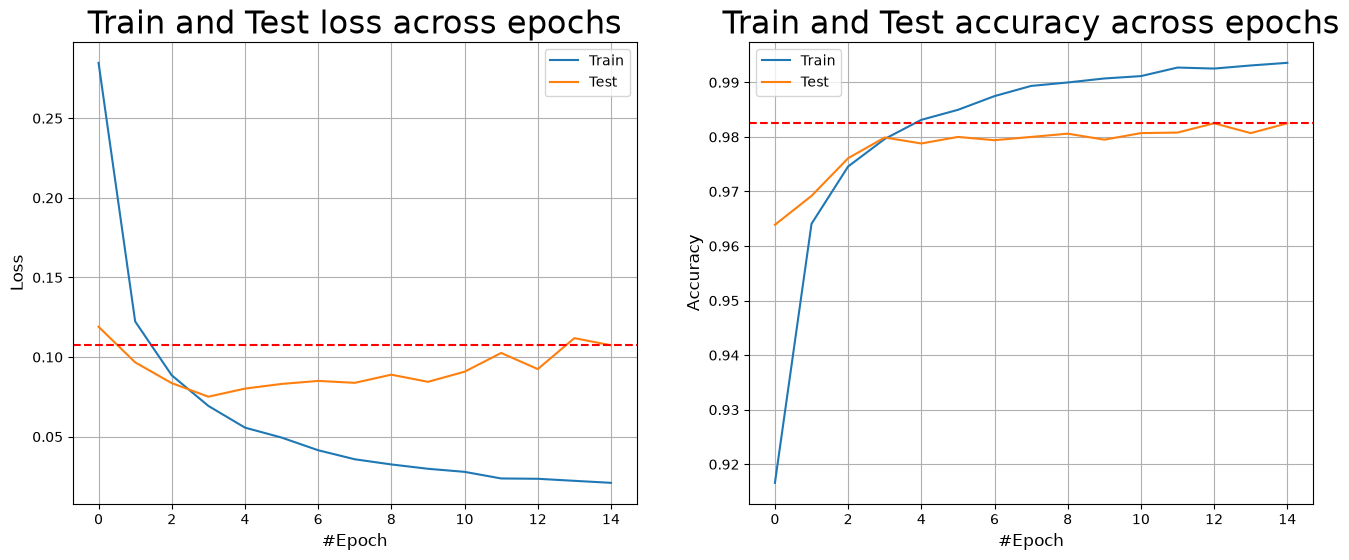

Model performance:
Test loss =  0.10740797221660614
Test accuracy =  0.9825000166893005


In [8]:
plt.figure(figsize=(16,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.axhline(y=loss, color='r', linestyle='--')
plt.xlabel('#Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Train and Test loss across epochs', fontsize=23)
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['acc'], label='Train')
plt.plot(history.history['val_acc'], label='Test')
plt.axhline(y=accuracy, color='r', linestyle='--')
plt.xlabel('#Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Train and Test accuracy across epochs', fontsize=23)
plt.grid(True)
plt.legend()

plt.show()

print('Model performance:')
print('Test loss = ', loss)
print('Test accuracy = ', accuracy)

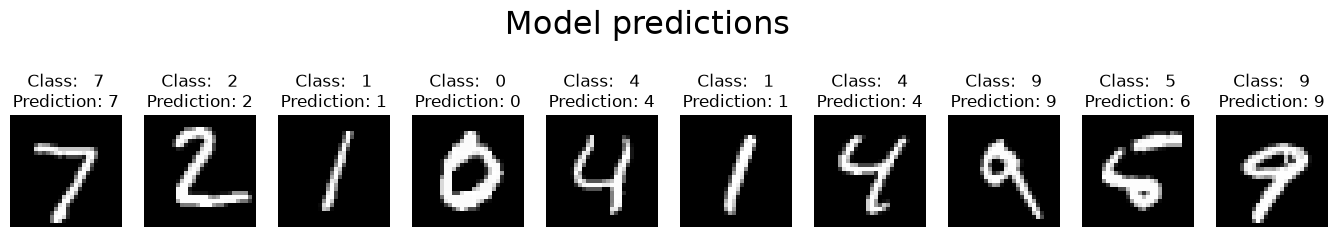

In [9]:
predictions = model.predict(X_test, verbose=0)

X = X_test.reshape(X_test.shape[0], rows, cols,1)

plt.figure(figsize=(17,17)) 
plt.suptitle('Model predictions', fontsize=23, y=0.8)
for i in range(10):    
    ax = plt.subplot(2, 10, i+1)    
    plt.imshow(X[i, :, :, 0], cmap='gray')    
    plt.title("Class:   {}\nPrediction: {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
    
plt.show()

I risultati ottenuti evidenziano che il modello costruito è in grado di riconoscere le cifre scritte a mano del dataset MNIST con una accuracy del $98\%$. 

Si osserva anche che la test loss si stabilizza a valori maggiori della training loss, la quale mantiene un andamento decrescente. Un modello di DNN di questo tipo impara molto bene dal training set, ma non è in grado di migliorare la sua capacità di generalizzazione oltre una certa soglia.

### <span style= "color: black" > Es12.2

In questa fase dell'esercitazione, si utilizza un CNN. Ci si aspetta che esso risulti più adatto per l'analisi di immagini, in quanto è progettato per riconoscere caratteristice locali e correlazioni spaziali. Per poter utilizzare un CNN, è necessario preservare la forma originale (bidimensionale) delle immagini, anziché trasferirle in vettori unidimensionali. 

Il procedimento da seguire è analogo a quello dell'esercizio precedente. Si è scelto di utilizzare $N_{\mathrm{epochs}}=15$ e l'ottimizzatire `adam`, come nel caso precedente.

In [3]:
# Step #1: Data loading and preprocessing

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()  # Create the training and test sets

X_train = X_train.reshape(X_train.shape[0], rows, cols, 1)  # Preserve the original image shapes
X_test = X_test.reshape(X_test.shape[0], rows, cols, 1)
input_shape = (rows, cols, 1)

X_train = X_train.astype('float32')/255         # Rescale each pixel value to [0,1]
X_test = X_test.astype('float32')/255

Y_train = keras.utils.to_categorical(Y_train, classes)   # Convert the class vectors into binary class matrices
Y_test = keras.utils.to_categorical(Y_test, classes)


# Step #2: Definition of the neural network type (CNN) and its architecture
def create_CNN():
    model = Sequential()                              # Neural network model
    model.add(Input(shape=input_shape))               # Input variable
    model.add(Conv2D(32, (3,3), activation='relu'))   # First convolutional block (convolution, pooling, dropout)
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3,3), activation='relu'))   # Second convolutional block (convolution, pooling, dropout)
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))
    model.add(Flatten())                              # 
    model.add(Dense(128, activation='relu'))          # Dense layer
    model.add(Dropout(0.5))                           # Apply dropout with rate=0.5
    model.add(Dense(classes, activation='softmax'))   # Softmax layer
    return model


# Step #3: Selection of the optimizer, loss function, and metrics (model compilation)
def compile_CNN(optimizer):
    model=create_CNN()     # Create the model
    model.compile(loss=keras.losses.categorical_crossentropy,optimizer=optimizer,metrics=['acc'])  # Compile the model
    return model


# Step #4: Model training
def train_CNN(optimizer, N_epochs):
    model = compile_CNN(optimizer)  # Create the CNN
    history = model.fit(X_train, Y_train, batch_size=32, epochs=N_epochs, shuffle=True, verbose=0, validation_data=(X_test, Y_test))  # Train the CNN
    loss, accuracy = model.evaluate(X_test, Y_test, batch_size=32, verbose=0)  # Evaluate the model on the test set
    return model, history, loss, accuracy


In [4]:
# CNN
model, history, loss, accuracy = train_CNN(optimizer='adam', N_epochs=15)

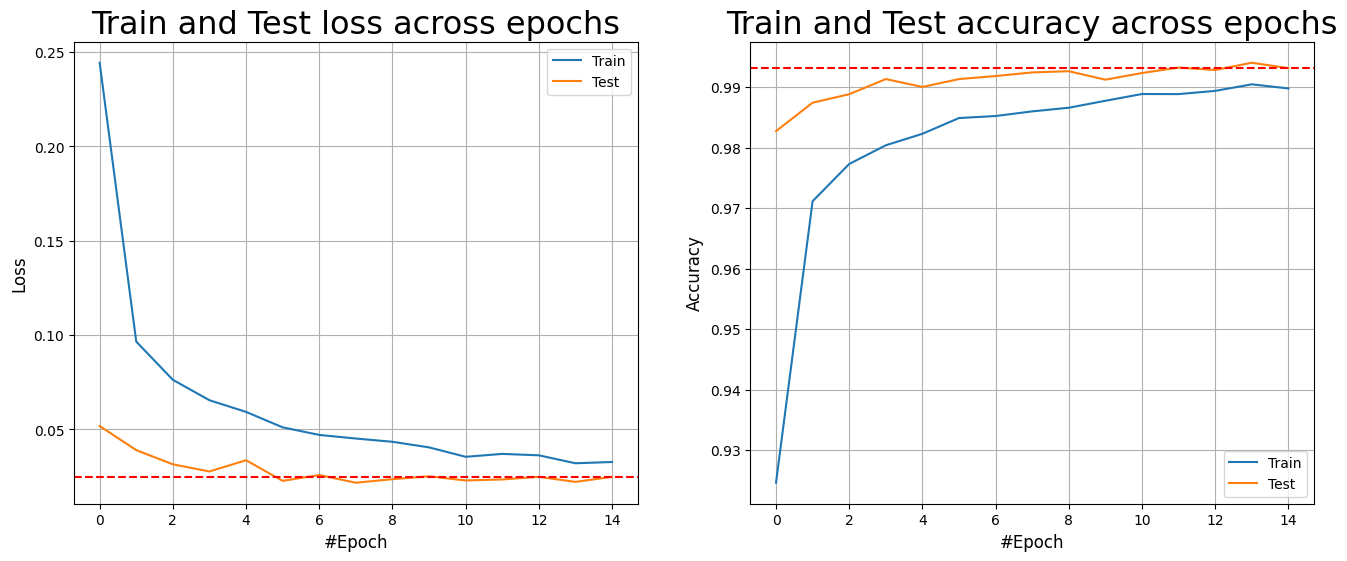

Model performance:
Test loss =  0.024836938828229904
Test accuracy =  0.9930999875068665


In [5]:
plt.figure(figsize=(16,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.axhline(y=loss, color='r', linestyle='--')
plt.xlabel('#Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Train and Test loss across epochs', fontsize=23)
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['acc'], label='Train')
plt.plot(history.history['val_acc'], label='Test')
plt.axhline(y=accuracy, color='r', linestyle='--')
plt.xlabel('#Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Train and Test accuracy across epochs', fontsize=23)
plt.grid(True)
plt.legend()

plt.show()

print('Model performance:')
print('Test loss = ', loss)
print('Test accuracy = ', accuracy)

In questo caso, i risultati ottenuti evidenziano che il modello costruito è in grado di riconoscere le cifre scritte a mano del dataset MNIST con una accuracy del $99.3\%$. La loss sul validation set converge rapidamente verso valori $\approx0.02$.

Rispetto alla DNN precedente, la CNN mostra un miglioramento significativo delle prestazioni, confermando che l’utilizzo di layer convoluzionali permette di sfruttare in modo più efficace la struttura spaziale delle immagini.

Le curve di train e test risultano inoltre molto vicine tra loro, indicando una buona capacità di generalizzazione e l’assenza di fenomeni evidenti di overfitting.

### <span style= "color: black" > Es12.3
  
In questo esercizio è stato verificato il funzionamento della CNN addestrata nel punto precedente utilizzando $10$ immagini realizzate manualmente.

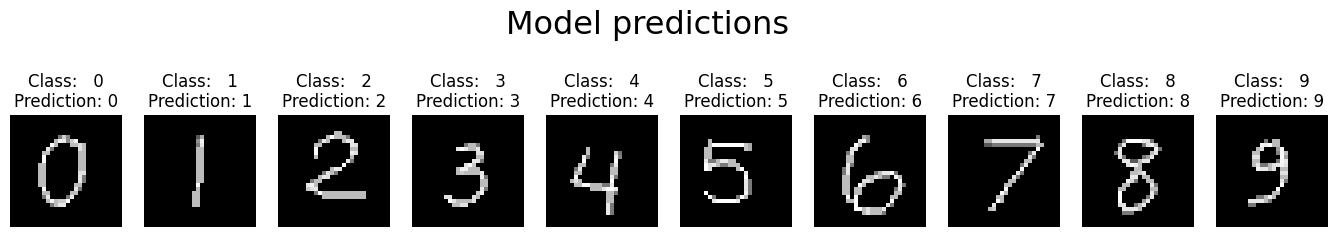

In [6]:
digit_filenames = [ "digits/0.png", "digits/1.png", "digits/2.png", "digits/3.png", "digits/4.png",
                    "digits/5.png", "digits/6.png", "digits/7.png", "digits/8.png", "digits/9.png", ]
data = []

for digit_filename in digit_filenames:
    digit_in = Image.open(digit_filename).convert('L').resize((28, 28))
    xdim, ydim = digit_in.size
    img = np.asarray(digit_in, dtype=np.float32)/255
    data.append(img)
    
predictions = [0]*10
for i in range(10):
    arr4d = data[i].reshape(1, 28, 28, 1)
    predictions[i] = model.predict(arr4d, verbose=0)
    
plt.figure(figsize=(17,17))     
plt.suptitle('Model predictions', fontsize=23, y=0.8)
for i in range(10):    
    ax = plt.subplot(2, 10, i+1)    
    plt.imshow(data[i], cmap='gray')    
    plt.title("Class:   "+str(i)+"\nPrediction: {}".format(np.argmax(predictions[i])))    
    plt.axis('off') 

plt.show()

Il CNN realizzato ha quindi classificato correttamente tutte le $10$ cifre fornite, mostrando una buona capacità di generalizzazione anche su immagini esterne al dataset originale